# 04 - Interpretação dos Clusters

Este notebook interpreta os resultados do clustering e responde às perguntas de pesquisa.

In [31]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import pickle
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

DATA_PROCESSED = project_root / 'data' / 'processed'

print('✓ Imports realizados')

✓ Imports realizados


In [32]:
# Carregar dados e labels
import pandas as pd
import numpy as np

DATA_PROCESSED = project_root / 'data' / 'processed'

# Carregar dados com clusters (do notebook 03)
escolas_com_clusters_path = DATA_PROCESSED / 'escolas_com_clusters.csv'

if escolas_com_clusters_path.exists():
    # Carregar clusters
    df_clusters = pd.read_csv(escolas_com_clusters_path)
    print(f'✓ Clusters carregados: {len(df_clusters)} escolas')
    print(f'  Colunas: {df_clusters.columns.tolist()}')
    
    # Verificar se temos os dados originais com tipo de escola
    # Os dados originais estao em ../microdados_enem_2024/DADOS/RESULTADOS_2024.csv
    # Mas vamos tentar carregar do parquet primeiro
    try:
        df_escolas_raw = pd.read_parquet(DATA_PROCESSED / 'dados_escolas.parquet')
        print(f'\n✓ Dados originais carregados: {len(df_escolas_raw)} escolas')
        print(f'  Colunas originais: {df_escolas_raw.columns.tolist()}')
        
        # Fazer merge pelo CO_ESCOLA (correto - nao pelo indice)
        df_escolas = df_escolas_raw.merge(
            df_clusters[['CO_ESCOLA', 'cluster']],
            on='CO_ESCOLA',
            how='left'
        )
        print(f'  Merge realizado: {len(df_escolas)} escolas com clusters')
        
    except Exception as e:
        print(f'\n⚠️ Erro ao carregar parquet: {e}')
        print('Usando apenas dados de clusters (sem informacao de tipo de escola)')
        df_escolas = df_clusters.copy()
else:
    print('⚠️ Arquivo escolas_com_clusters.csv nao encontrado')
    raise FileNotFoundError('Execute o notebook 03 primeiro')

print(f'\n✓ Dataset final: {len(df_escolas)} escolas x {len(df_escolas.columns)} colunas')
print(f'Clusters: {sorted(df_escolas["cluster"].unique())}')

# Verificar colunas disponiveis
print('\nColunas disponiveis:')
for col in df_escolas.columns:
    print(f'  - {col}')

✓ Clusters carregados: 23023 escolas
  Colunas: ['CO_ESCOLA', 'TP_DEPENDENCIA_ADM_ESC', 'QTD_ALUNOS', 'MEDIA_GERAL', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'cluster', 'cluster_kmeans', 'cluster_dbscan', 'cluster_hierarchical', 'cluster_gmm']

✓ Dados originais carregados: 23023 escolas
  Colunas originais: ['CO_ESCOLA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC', 'CO_UF_ESC', 'TP_LOCALIZACAO_ESC', 'QTD_ALUNOS', 'MEDIA_GERAL', 'STD_NOTAS', 'NOTA_MAX', 'NOTA_MIN', 'DIF_MT_LC', 'DIF_CN_CH', 'PCT_NU_NOTA_CN', 'PCT_NU_NOTA_CH', 'PCT_NU_NOTA_LC', 'PCT_NU_NOTA_MT', 'PCT_NU_NOTA_REDACAO']
  Merge realizado: 23023 escolas com clusters

✓ Dataset final: 23023 escolas x 22 colunas
Clusters: [np.int64(0), np.int64(1)]

Colunas disponiveis:
  - CO_ESCOLA
  - NU_NOTA_CN
  - NU_NOTA_CH
  - NU_NOTA_LC
  - NU_NOTA_MT
  - NU_NOTA_REDACAO
  - TP_DEPENDENCIA_ADM_ESC
  - CO_UF_ESC
  - TP_LOCALIZACAO_ESC
  - QTD_ALU

## 1. Perfil dos Clusters

In [33]:
# Funcao para analisar perfil dos clusters
def analisar_perfil_clusters(df, labels, coluna_escola='CO_ESCOLA'):
    df_analysis = df.copy()
    df_analysis['cluster'] = labels
    
    perfil = {}
    for cluster in sorted(df_analysis['cluster'].unique()):
        subset = df_analysis[df_analysis['cluster'] == cluster]
        perfil[cluster] = {
            'quantidade': len(subset),
            'percentual': len(subset) / len(df_analysis) * 100
        }
    
    return pd.DataFrame(perfil).T

print('Funcao de analise criada')

Funcao de analise criada


## 2. Responder Pergunta 1: Tipos de Escolas

Colunas disponiveis que podem indicar tipo de escola:
['TP_DEPENDENCIA_ADM_ESC']

Todas as colunas:
  - CO_ESCOLA
  - NU_NOTA_CN
  - NU_NOTA_CH
  - NU_NOTA_LC
  - NU_NOTA_MT
  - NU_NOTA_REDACAO
  - TP_DEPENDENCIA_ADM_ESC
  - CO_UF_ESC
  - TP_LOCALIZACAO_ESC
  - QTD_ALUNOS
  - MEDIA_GERAL
  - STD_NOTAS
  - NOTA_MAX
  - NOTA_MIN
  - DIF_MT_LC
  - DIF_CN_CH
  - PCT_NU_NOTA_CN
  - PCT_NU_NOTA_CH
  - PCT_NU_NOTA_LC
  - PCT_NU_NOTA_MT
  - PCT_NU_NOTA_REDACAO
  - cluster

Distribuicao percentual por tipo de escola:
tipo_escola  Estadual  Federal  Municipal  Privada
cluster                                           
0                94.5      0.7        0.5      4.3
1                15.5      6.5        0.3     77.6


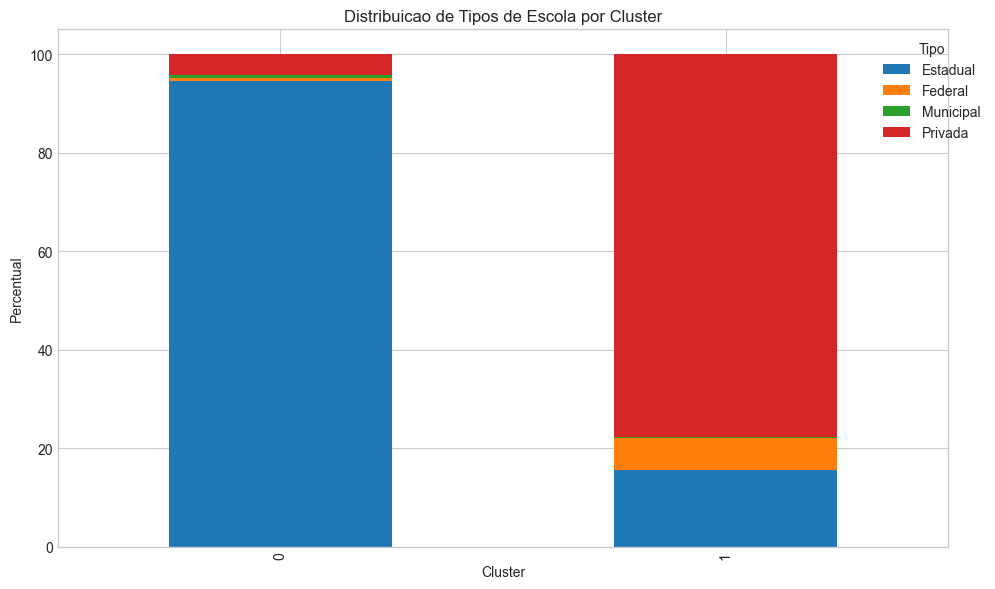

In [34]:
# Analise dos tipos de escolas por cluster
def analisar_tipos_escola(df):
    df_analysis = df.copy()
    
    # Verificar quais colunas de tipo de escola existem
    colunas_tipo = [c for c in df_analysis.columns if 'DEPENDENCIA' in c.upper() or 'TIPO' in c.upper()]
    
    print('Colunas disponiveis que podem indicar tipo de escola:')
    print(colunas_tipo if colunas_tipo else '  (nenhuma encontrada)')
    print('\nTodas as colunas:')
    for c in df_analysis.columns:
        print(f'  - {c}')
    
    coluna_tipo = 'TP_DEPENDENCIA_ADM_ESC' if 'TP_DEPENDENCIA_ADM_ESC' in df_analysis.columns else None
    
    if coluna_tipo:
        tipo_map = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
        df_analysis['tipo_escola'] = df_analysis[coluna_tipo].map(tipo_map).fillna('Outro')
        
        crosstab = pd.crosstab(df_analysis['cluster'], df_analysis['tipo_escola'], normalize='index') * 100
        print('\nDistribuicao percentual por tipo de escola:')
        print(crosstab.round(1))
        
        crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
        plt.title('Distribuicao de Tipos de Escola por Cluster')
        plt.xlabel('Cluster')
        plt.ylabel('Percentual')
        plt.legend(title='Tipo', bbox_to_anchor=(1.05, 1))
        plt.tight_layout()
        plt.show()
    else:
        print('\n⚠️ Coluna TP_DEPENDENCIA_ADM_ESC nao encontrada nos dados!')
        print('Isso pode ocorrer se os dados originais do ENEM nao incluirem essa informacao.')
        print('A analise de tipos de escola nao podera ser realizada.')
        print('\nPara incluir essa informacao, voce precisa:')
        print('1. Verificar se o arquivo RESULTADOS_2024.csv tem a coluna TP_DEPENDENCIA_ADM_ESC')
        print('2. Se sim, reprocessar os dados incluindo essa coluna no notebook 02')

analisar_tipos_escola(df_escolas)

## 3. Responder Pergunta 2: Escolas Publicas Estaduais

In [35]:
# Analise das escolas publicas estaduais
def analisar_estaduais(df):
    df_analysis = df.copy()
    coluna_tipo = 'TP_DEPENDENCIA_ADM_ESC' if 'TP_DEPENDENCIA_ADM_ESC' in df_analysis.columns else None
    
    if coluna_tipo:
        estaduais = df_analysis[df_analysis[coluna_tipo] == 2]
        print(f'Total estaduais: {len(estaduais)} ({len(estaduais)/len(df_analysis)*100:.1f}%)')
        
        if len(estaduais) > 0:
            print('\nDistribuicao dos clusters:')
            distr = estaduais['cluster'].value_counts(normalize=True).sort_index() * 100
            print(distr.round(1))
            
            geral = df_analysis['cluster'].value_counts(normalize=True).sort_index() * 100
            comparacao = pd.DataFrame({'Estaduais': distr, 'Geral': geral}).fillna(0)
            comparacao['Diferenca'] = comparacao['Estaduais'] - comparacao['Geral']
            print('\nComparacao:')
            print(comparacao.round(1))
    else:
        print('⚠️ Analise de estaduais nao disponivel - coluna TP_DEPENDENCIA_ADM_ESC nao encontrada')

analisar_estaduais(df_escolas)

Total estaduais: 15844 (68.8%)

Distribuicao dos clusters:
cluster
0    92.6
1     7.4
Name: proportion, dtype: float64

Comparacao:
         Estaduais  Geral  Diferenca
cluster                             
0             92.6   67.4       25.2
1              7.4   32.6      -25.2


## 4. Responder Pergunta 3: Fatores de Alto Desempenho

In [36]:
# Fatores que distinguem alto desempenho
def analisar_fatores_desempenho(df):
    colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
    colunas_notas = [c for c in colunas_notas if c in df.columns]
    
    df_analysis = df.copy()
    df_analysis['MEDIA_GERAL'] = df_analysis[colunas_notas].mean(axis=1)
    
    media_por_cluster = df_analysis.groupby('cluster')['MEDIA_GERAL'].mean().sort_values(ascending=False)
    melhor_cluster = media_por_cluster.index[0]
    pior_cluster = media_por_cluster.index[-1]
    
    print('Media por cluster:')
    for c, m in media_por_cluster.items():
        print(f'  Cluster {c}: {m:.2f}')
    
    print(f'\nMelhor: Cluster {melhor_cluster}')
    print(f'Pior: Cluster {pior_cluster}')
    
    melhor = df_analysis[df_analysis['cluster'] == melhor_cluster]
    pior = df_analysis[df_analysis['cluster'] == pior_cluster]
    
    print('\nDiferencas por area:')
    for col in colunas_notas:
        diff = melhor[col].mean() - pior[col].mean()
        print(f'  {col}: +{diff:.1f}')
    
    coluna_tipo = 'TP_DEPENDENCIA_ADM_ESC' if 'TP_DEPENDENCIA_ADM_ESC' in df_analysis.columns else None
    if coluna_tipo:
        print(f'\nComposicao do melhor cluster:')
        tipo_map = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
        comp = melhor[coluna_tipo].map(tipo_map).value_counts(normalize=True) * 100
        for t, p in comp.items():
            print(f'  {t}: {p:.1f}%')
    
    return melhor_cluster

melhor = analisar_fatores_desempenho(df_escolas)

Media por cluster:
  Cluster 1: 604.29
  Cluster 0: 497.51

Melhor: Cluster 1
Pior: Cluster 0

Diferencas por area:
  NU_NOTA_CN: +75.9
  NU_NOTA_CH: +83.4
  NU_NOTA_LC: +59.3
  NU_NOTA_MT: +118.8
  NU_NOTA_REDACAO: +196.6

Composicao do melhor cluster:
  Privada: 77.6%
  Estadual: 15.5%
  Federal: 6.5%
  Municipal: 0.3%


## 5. Conclusoes

## 1. Existem tipos de escolas?
   Sim, dois grupos bem definidos:
| Cluster | % Estadual | % Privada | Média ENEM |
| :--- | :---: | ---: |  :--- 
| 0 (Baixo)	 | 94.5% | 4.3% |  497.51 |
| 1 (Alto) | 15.5%	 | 77.6% |  604.29 |

> Conclusão: Sim, existem dois tipos claros: escolas públicas estaduais de baixo desempenho (67% do total) e escolas privadas de alto desempenho (33% do total).




## 2. Escolas publicas estaduais se agrupam?
  SIM, fortemente no cluster de baixo desempenho:

 - 92.6% das estaduais estão no Cluster 0 (baixo) = 14,679 escolas
 - Apenas 7.4% das estaduais estão no Cluster 1 (alto) = 1,165 escolas
>Conclusão: As escolas estaduais se concentram massivamente no cluster de baixo desempenho (92.6%), com apenas uma minoria (7.4%) conseguindo alto desempenho.


## 3. Fatores de alto desempenho:

| Fator | Evidência | 
| :--- | :--- |
| 1. Dependência Administrativa (Privada) | 77.6% das escolas de alto desempenho são privadas | 
| 2. Dependência Administrativa (Federal) | 6.5% no alto vs 0.7% no baixo (9x mais) | 
| Redação | Diferença de 196 pontos (762 vs 566) - maior gap | |
| Matemática | Diferença de 119 pontos (601 vs 482) |
> IMPORTANTE - Limitação: Correlação ≠ Causalidade. A análise mostra ASSOCIAÇÃO entre ser privada e alto desempenho, mas não prova que a privatização causa o sucesso. A presença de 1,165 escolas estaduais no cluster de alto desempenho mostra que é possível ter sucesso no setor público.